In [101]:
import pandas as pd

data = pd.read_csv("../data/Clean_Dataset.csv")


data = data.rename(columns={"Unnamed: 0": "id"})
data.drop_duplicates()

columns = []

for single_data in data :
    if data[single_data][0] == str:
        columns.append(single_data)

for col in columns:
    data[col] = data[col].str.strip()


stop_to_float = {"zero": 0, "one": 1, "two_or_more": 2}
data["stops"] = data["stops"].replace(stop_to_float)

data["price"] = data["price"].astype(float)
data["days_left"] = data["days_left"].astype(float)
data["duration"] = data["duration"].astype(float)

data = data.drop(columns=["flight", "id"])

print(data)


         airline source_city departure_time stops   arrival_time  \
0       SpiceJet       Delhi        Evening     0          Night   
1       SpiceJet       Delhi  Early_Morning     0        Morning   
2        AirAsia       Delhi  Early_Morning     0  Early_Morning   
3        Vistara       Delhi        Morning     0      Afternoon   
4        Vistara       Delhi        Morning     0        Morning   
...          ...         ...            ...   ...            ...   
300148   Vistara     Chennai        Morning     1        Evening   
300149   Vistara     Chennai      Afternoon     1          Night   
300150   Vistara     Chennai  Early_Morning     1          Night   
300151   Vistara     Chennai  Early_Morning     1        Evening   
300152   Vistara     Chennai        Morning     1        Evening   

       destination_city     class  duration  days_left    price  
0                Mumbai   Economy      2.17        1.0   5953.0  
1                Mumbai   Economy      2.33        

In [ ]:
categorical = ["stops", "class", "departure_time", "arrival_time"]
ordinal = ["airline", "flight", "destination_city"]
quantitative = ["duration", "days_left", "price"]
cible = ["price"]

for category in categorical:
    freq = data[category].value_counts()
    rep = (data[category].value_counts() / data[category].count()) * 100
    dom = rep.index[0]
    max_pct = rep.iloc[0]
    min_pct = rep.iloc[-1]  

    print(f"{rep.index[0]} {max_pct}")
    print(f"{rep.index[-1]} {min_pct}")
    print(f"{rep.index[0]} is the most chosen")

stats = data.describe()

print(stats)

one 83.57837502873534
two_or_more 4.4264091979756985
one is the most chosen
Economy 68.85355135547537
Business 31.146448644524625
Economy is the most chosen
Morning 23.703244678547275
Late_Night 0.4351114265058154
Morning is the most chosen
Night 30.497113138965794
Late_Night 4.664621043267933
Night is the most chosen


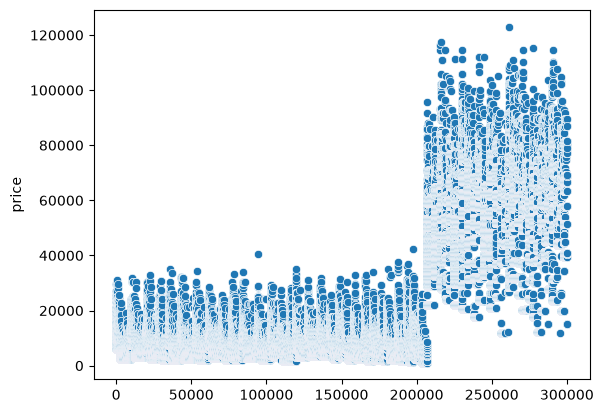

In [3]:
    
import seaborn as sns
import matplotlib.pyplot as plt


sns.scatterplot(data['price'])
plt.show()


In [ ]:
price_per_hour = data["price_per_hour"] = data["price"] / data["duration"]
price_by_stop = data.groupby("stops")["price"].sum()
airline_revenue_by_flight = data.groupby("airline")["price"].mean()
price_by_days_left = data.groupby("days_left")["price"].sum()
print(price_per_hour)
print(airline_revenue_by_flight)
print(price_by_stop)
print(price_by_days_left)

0         2743.317972
1         2554.935622
2         2744.700461
3         2646.666667
4         2555.793991
             ...     
300148    6871.527778
300149    7399.712092
300150    5719.378163
300151    8158.500000
300152    8093.750000
Length: 300153, dtype: float64
airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64
Series([], Name: price, dtype: float64)
days_left
1.0      41607528.0
2.0     121630693.0
3.0     123090403.0
4.0     130635808.0
5.0     143857338.0
6.0     142676275.0
7.0     145930459.0
8.0     143574563.0
9.0     145739184.0
10.0    148884953.0
11.0    147531040.0
12.0    143609531.0
13.0    144082862.0
14.0    143982637.0
15.0    139179109.0
16.0    128598242.0
17.0    130860006.0
18.0    131957113.0
19.0    127521687.0
20.0    128089292.0
21.0    125890171.0
22.0    127221794.0
23.0    127001687.0
24.0    129557172.0
25.0 

In [102]:
nominal_cols = [
    "class",
    "airline",
    "source_city",
    "departure_time",
    "arrival_time",
    "destination_city",
]

encoded_cat = pd.get_dummies(data, columns=nominal_cols, dtype=int)

final_features = encoded_cat.drop(columns=["price"])
target = encoded_cat["price"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor

x = final_features
y = target

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    train_size=0.8,
    random_state=42,
)

dummy_model = DummyRegressor(strategy="mean")

dummy_model.fit(x_train, y_train)

dummy_pred = dummy_model.predict(x_test)
dummy_mae = mean_absolute_error(y_test, dummy_pred)

print(dummy_mae)

model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

linear_mae = mean_absolute_error(y_test, y_pred)
linear_mse = mean_squared_error(y_test, y_pred)
linear_rmse = linear_mse ** 0.5
linear_r2 = r2_score(y_test, y_pred)
print(linear_mse)
print(linear_rmse)
print(linear_r2)
print(linear_mae)

ridge_model = Ridge(alpha=1)

ridge_model.fit(x_train,y_train)

y_pred_ridge = ridge_model.predict(x_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print(mae_ridge)

model_rand_forest = RandomForestRegressor(n_estimators=100, random_state=42)
model_rand_forest.fit(x_train, y_train)


y_pred_rf = model_rand_forest.predict(x_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(mae_rf)

19768.69424587037
46443347.71222663
6814.935635222583
0.9099031138535913
4500.712501541964
4500.696062322511
